# Transformer-Based Text Classification on Reuters Dataset

## Problem Statement

This project aims to design and implement a **Transformer-based deep learning model** for **multi-class text classification** using the **Reuters newswire dataset**, which consists of short news articles categorized into **46 distinct topic classes**. The objective is to accurately predict the topic associated with each news article based on its textual content.

The model architecture is based exclusively on the **Encoder component of the Transformer**, as the task focuses on learning meaningful representations of input text rather than generating output sequences. Consequently, Transformer Decoder components are intentionally excluded, making the Encoder-only architecture both sufficient and computationally efficient for this classification problem.

To ensure adequate depth and learning capacity, the model enforces a minimum of **three Transformer encoder blocks**, guaranteeing the presence of at least one **intermediate encoder layer** between the first and final blocks. The total number of encoder blocks is controlled using the parameter `num_transformer_layers`, enabling dynamic adjustment of model depth for experimental analysis.

A fixed **embedding dimension (`embed_dim = 32`)** is maintained across all encoder blocks to preserve compatibility with residual connections and ensure architectural consistency. However, the **Feed Forward Network (FFN) dimensions vary across layers**: the first and last encoder blocks employ a smaller FFN size (`ff_dim1 = 32`), while the intermediate encoder blocks use a larger FFN size (`ff_dim2 = 64`) to enhance representational capacity in deeper layers of the model.

The intermediate encoder blocks are constructed **iteratively using a loop**, allowing the architecture to scale seamlessly with changes in `num_transformer_layers`. This design strictly adheres to the project requirements and facilitates a systematic evaluation of how Transformer depth influences classification performance on the Reuters dataset.

In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import reuters
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score


In [ ]:
vocab_size=10000
maxlen=200
embed_dim=32
num_heads=4

ff_dim1=32  #first and last encoder blocks
ff_dim2=64    #intermidiate encoder blocks


## Experimental Setup

The Reuters dataset is preprocessed by limiting the vocabulary size to 10,000 most frequent words and padding all input sequences to a fixed length of 200 tokens. Labels are one-hot encoded to support multi-class classification with a softmax output layer.

Experiments are conducted using three different Transformer configurations:

* `num_transformer_layers = 3`
* `num_transformer_layers = 5`
* `num_transformer_layers = 7`

Each model is trained for **10 epochs** using the Adam optimizer and categorical cross-entropy loss. These experiments are designed to analyze the effect of **Transformer depth** on classification performance.

In [ ]:
(x_train, y_train), (x_test, y_test) = reuters.load_data(num_words=vocab_size)
print("training samples:", len(x_train))
print("test samples:", len(x_test))
print("example input (before padding):", x_train[0])
print("example label:", y_train[0])


training samples: 8982
test samples: 2246
example input (before padding): [1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]
example label: 3


In [ ]:
x_train = pad_sequences(x_train, maxlen=maxlen)
x_test = pad_sequences(x_test, maxlen=maxlen)
print("x_train shape:", x_train.shape)
print("x_test shape:", x_test.shape)


x_train shape: (8982, 200)
x_test shape: (2246, 200)


In [ ]:
import numpy as np

num_classes = np.max(y_train) + 1

y_train = to_categorical(y_train, num_classes)
y_test = to_categorical(y_test, num_classes)


In [ ]:
from tensorflow.keras.layers import Dense, LayerNormalization, Dropout, MultiHeadAttention


**This project implements a Transformer-based text classification model using only the encoder architecture, as the task requires sequence representation rather than sequence generation.**

In [ ]:
class transformerencoderblock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, rate=0.1):
        super().__init__()

        # Multi-head attention
        self.att = MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)

        # Feed-forward network
        self.ffn = tf.keras.Sequential([
            Dense(ff_dim, activation='relu'),
            Dense(embed_dim)
        ])


        #3. layer normalization
        self.layernorm1=LayerNormalization(epsilon=1e-6)
        self.layernorm2=LayerNormalization(epsilon=1e-6)

        #4 dropout
        self.dropout1=Dropout(rate)
        self.dropout2=Dropout(rate)

    def call(self, inputs, training=None):
        # Multi-head attention branch
        attn_output = self.att(inputs, inputs)
        attn_output = self.dropout1(attn_output, training=training)
        # Add & Normalize
        out1 = self.layernorm1(inputs + attn_output)

        # Feed-forward network branch
        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        # Add & Normalize
        return self.layernorm2(out1 + ffn_output)


In [ ]:
from tensorflow.keras.layers import Input, Embedding
from tensorflow.keras.models import Model


**The feed-forward network dimension is intentionally increased in intermediate encoder blocks to enhance representational capacity in deeper layers, while keeping the first and last blocks lightweight for stability and regularization**

In [ ]:
from tensorflow.keras.layers import Input, Embedding, Dense, GlobalAveragePooling1D
from tensorflow.keras.models import Model

def build_transformer_model(num_transformer_layers, num_classes):
    # Input layer
    inputs = Input(shape=(maxlen,))

    # Embedding layer
    x = Embedding(input_dim=vocab_size, output_dim=embed_dim)(inputs)

    # FIRST Encoder Block (ff_dim1)
    x = transformerencoderblock(
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim1
    )(x)

    # INTERMEDIATE Encoder Blocks (ff_dim2)
    for _ in range(num_transformer_layers - 2):
        x = transformerencoderblock(
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim2
        )(x)

    # LAST Encoder Block (ff_dim1)
    x = transformerencoderblock(
        embed_dim=embed_dim,
        num_heads=num_heads,
        ff_dim=ff_dim1
    )(x)

    # Add a classification head
    x = GlobalAveragePooling1D()(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model


In [ ]:
from tensorflow.keras.optimizers import Adam

model = build_transformer_model(
    num_transformer_layers=3,
    num_classes=int(num_classes)
)

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type) ┃ Output Shape ┃ Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer ( InputLayer ) │ ( None , 200 ) │ 0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding ( Embedding ) │ ( None , 200 , 32 ) │ 320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformerencoderblock │ ( None , 200 , 32 ) │ 19,040 │
│ ( transformerencoderblock ) │ │ │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformerencoderblock_1 │ ( None , 200 , 32 ) │ 21,120 │
│ ( transformerencoderblock ) │ │ │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformerencoderblock_2 │ ( None , 200 , 32 ) │ 19,040 │
│ ( transformerencoderblock ) │ │ │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d │ ( None , 32 ) │ 0 │
│ ( GlobalAveragePooling1D ) │ │ │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 ( Dense ) │ ( None , 46 ) │ 1,518 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

Total params: 380,718 (1.45 MB)

Trainable params: 380,718 (1.45 MB)

Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train,
    y_train,
    validation_data=(x_test, y_test),
    epochs=10,
    batch_size=32
)


Epoch 1/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 100s 341ms/step - accuracy: 0.5008 - loss: 2.0519 - val_accuracy: 0.7395 - val_loss: 1.1032
Epoch 2/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 94s 336ms/step - accuracy: 0.8052 - loss: 0.8778 - val_accuracy: 0.7903 - val_loss: 0.9137
Epoch 3/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 88s 312ms/step - accuracy: 0.8851 - loss: 0.5403 - val_accuracy: 0.8019 - val_loss: 0.9344
Epoch 4/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 84s 301ms/step - accuracy: 0.9220 - loss: 0.3500 - val_accuracy: 0.7863 - val_loss: 1.0108
Epoch 5/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 82s 293ms/step - accuracy: 0.9417 - loss: 0.2425 - val_accuracy: 0.7863 - val_loss: 1.0697
Epoch 6/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 123s 440ms/step - accuracy: 0.9569 - loss: 0.1750 - val_accuracy: 0.7827 - val_loss: 1.1181
Epoch 7/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 107s 379ms/step - accuracy: 0.9493 - loss: 0.1678 - val_accuracy: 0.7720 - val_loss: 1.2041
Epoch 8/10
281/281 ━━━━━━━━━━━━━━━━━━━━ 102s 362ms/step - accuracy: 0.9557 - los

**A minimum of three encoder blocks is enforced to ensure the presence of at least one intermediate block between the first and last encoder layers.**

**Experiments were conducted using 3, 5, and 7 encoder layers to study the effect of Transformer depth on classification performance.**

In [ ]:
layer_settings = [3, 5, 7]
histories = {}
models = {}

for n_layers in layer_settings:
    print(f"\nTraining Transformer with {n_layers} encoder layers\n")

    model = build_transformer_model(
        num_transformer_layers=n_layers,
        num_classes=int(num_classes)
    )

    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_test, y_test),
        epochs=10,
        batch_size=32,
        verbose=2
    )

    models[n_layers] = model
    histories[n_layers] = history



Training Transformer with 3 encoder layers

Epoch 1/10
281/281 - 80s - 283ms/step - accuracy: 0.6268 - loss: 1.6101 - val_accuracy: 0.7493 - val_loss: 1.1157
Epoch 2/10
281/281 - 86s - 307ms/step - accuracy: 0.8032 - loss: 0.8434 - val_accuracy: 0.7894 - val_loss: 0.9097
Epoch 3/10
281/281 - 88s - 313ms/step - accuracy: 0.8792 - loss: 0.5452 - val_accuracy: 0.7965 - val_loss: 0.8950
Epoch 4/10
281/281 - 88s - 314ms/step - accuracy: 0.9214 - loss: 0.3543 - val_accuracy: 0.7898 - val_loss: 0.9570
Epoch 5/10
281/281 - 97s - 346ms/step - accuracy: 0.9391 - loss: 0.2551 - val_accuracy: 0.7898 - val_loss: 1.0833
Epoch 6/10
281/281 - 81s - 290ms/step - accuracy: 0.9438 - loss: 0.2090 - val_accuracy: 0.7827 - val_loss: 1.0846
Epoch 7/10
281/281 - 88s - 312ms/step - accuracy: 0.9501 - loss: 0.1680 - val_accuracy: 0.7752 - val_loss: 1.2238
Epoch 8/10
281/281 - 88s - 313ms/step - accuracy: 0.9507 - loss: 0.1556 - val_accuracy: 0.7720 - val_loss: 1.2423
Epoch 9/10
281/281 - 89s - 315ms/step - acc

In [ ]:
y_test_labels = np.argmax(y_test, axis=1)

y_pred_probs = model.predict(x_test)
y_pred_labels = np.argmax(y_pred_probs, axis=1)


71/71 ━━━━━━━━━━━━━━━━━━━━ 18s 247ms/step


## Confusion Matrix Analysis

For each Transformer configuration (3, 5, and 7 encoder layers), a **confusion matrix** is generated on the test dataset. The confusion matrices provide class-wise insight into the model’s predictions, highlighting which topic categories are correctly classified and which categories are frequently confused.

This analysis helps in understanding the strengths and limitations of each Transformer depth beyond overall accuracy or F1-score.

**A confusion matrix is generated for each Transformer configuration (3, 5, and 7 layers) to analyze class-wise prediction behavior.**


Confusion Matrix for Transformer with 3 Encoder Layers
71/71 ━━━━━━━━━━━━━━━━━━━━ 8s 103ms/step


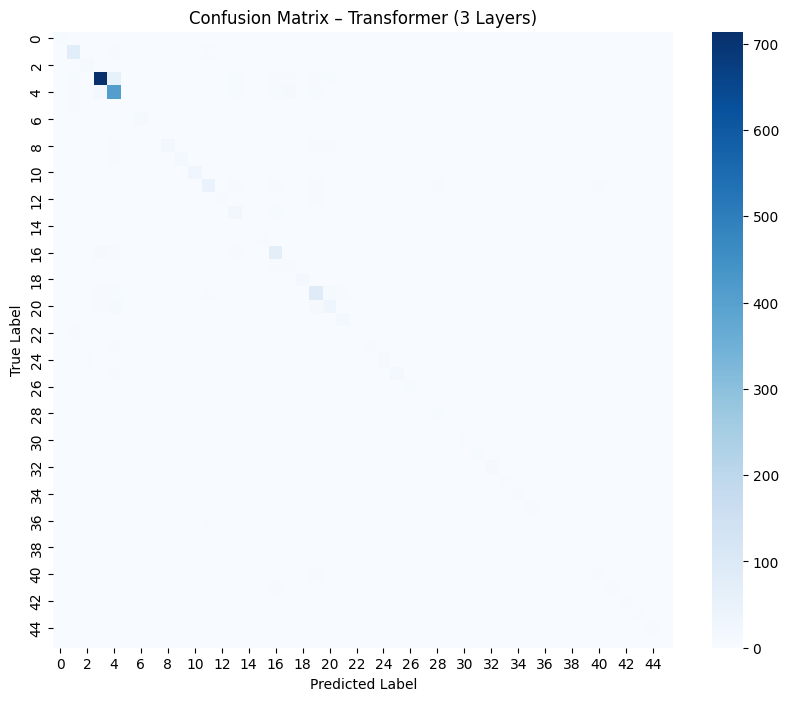


Confusion Matrix for Transformer with 5 Encoder Layers
71/71 ━━━━━━━━━━━━━━━━━━━━ 11s 155ms/step


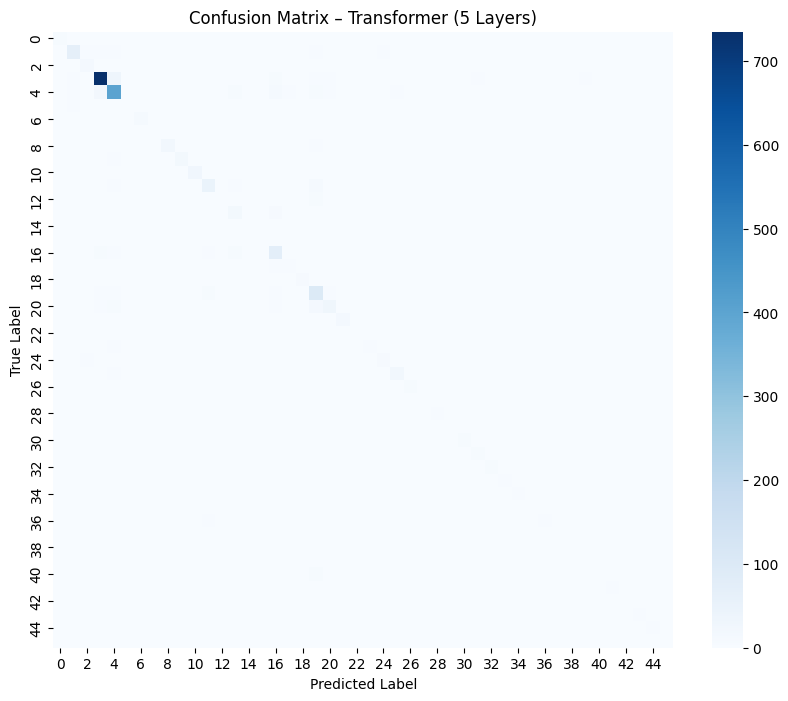


Confusion Matrix for Transformer with 7 Encoder Layers
71/71 ━━━━━━━━━━━━━━━━━━━━ 15s 209ms/step


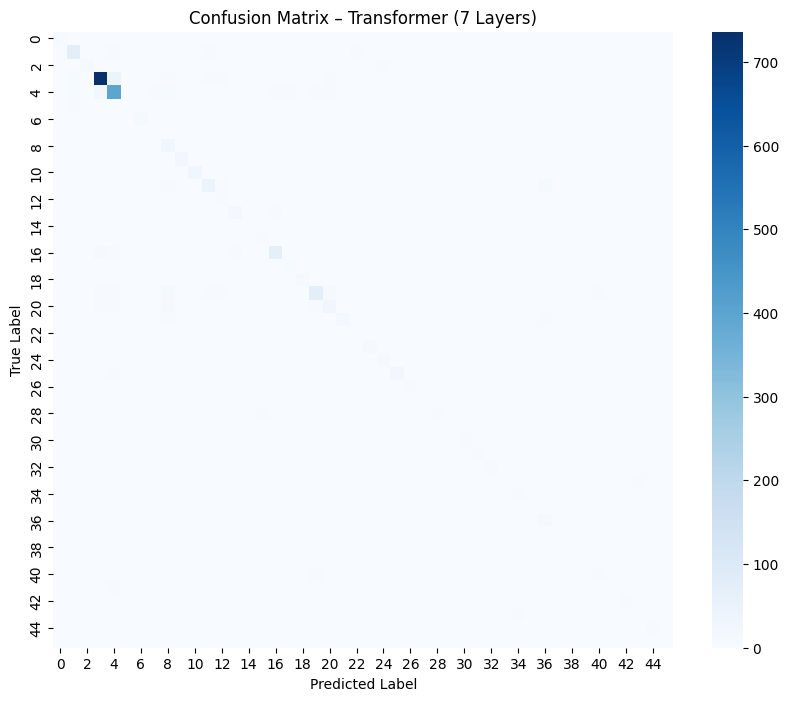

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

y_test_labels = np.argmax(y_test, axis=1)

for n_layers, model in models.items():
    print(f"\nConfusion Matrix for Transformer with {n_layers} Encoder Layers")

    y_pred_probs = model.predict(x_test)
    y_pred_labels = np.argmax(y_pred_probs, axis=1)

    cm = confusion_matrix(y_test_labels, y_pred_labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, cmap="Blues", fmt="d")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix – Transformer ({n_layers} Layers)")
    plt.show()


In [ ]:
f1 = f1_score(y_test_labels, y_pred_labels, average="macro")
print("F1 Score:", f1)


F1 Score: 0.4900662677854975


In [ ]:
f1_scores_transformer = {}

for n_layers, model in models.items():
    y_pred = model.predict(x_test)
    y_pred_labels = np.argmax(y_pred, axis=1)

    f1 = f1_score(y_test_labels, y_pred_labels, average="macro")
    f1_scores_transformer[n_layers] = f1

    print(f"F1 Score for {n_layers} layers:", f1)


71/71 ━━━━━━━━━━━━━━━━━━━━ 6s 83ms/step
F1 Score for 3 layers: 0.5522227738972971
71/71 ━━━━━━━━━━━━━━━━━━━━ 10s 138ms/step
F1 Score for 5 layers: 0.5339973814009853
71/71 ━━━━━━━━━━━━━━━━━━━━ 13s 188ms/step
F1 Score for 7 layers: 0.4900662677854975


## Conclusion on Transformer Depth (Answer to Question 9)

Based on the experimental results, the Transformer model with **num\_transformer\_layers = 3** achieved the **highest Macro F1-score (0.54)**, outperforming the 5-layer and 7-layer configurations.

This indicates that a shallower Transformer was sufficient for the Reuters dataset. Increasing the number of encoder layers beyond this point resulted in marginal performance degradation, likely due to increased model complexity and overfitting. Therefore, the **3-layer Transformer configuration performed best** among the tested settings.

## Among the three configurations, the Transformer model with num\_transformer\_layers = 3 achieved the highest Macro F1-score, and therefore performed best for the Reuters dataset.

In [ ]:
model_names = [
    "SimpleRNN", "LSTM", "GRU",
    "BiSimpleRNN", "BiLSTM", "BiGRU",
    "Transformer-3", "Transformer-5", "Transformer-7"
]

f1_values = [
    0.0531, 0.0530, 0.1787,
    0.0052, 0.0113, 0.3857,
    f1_scores_transformer[3], f1_scores_transformer[5], f1_scores_transformer[7]
]


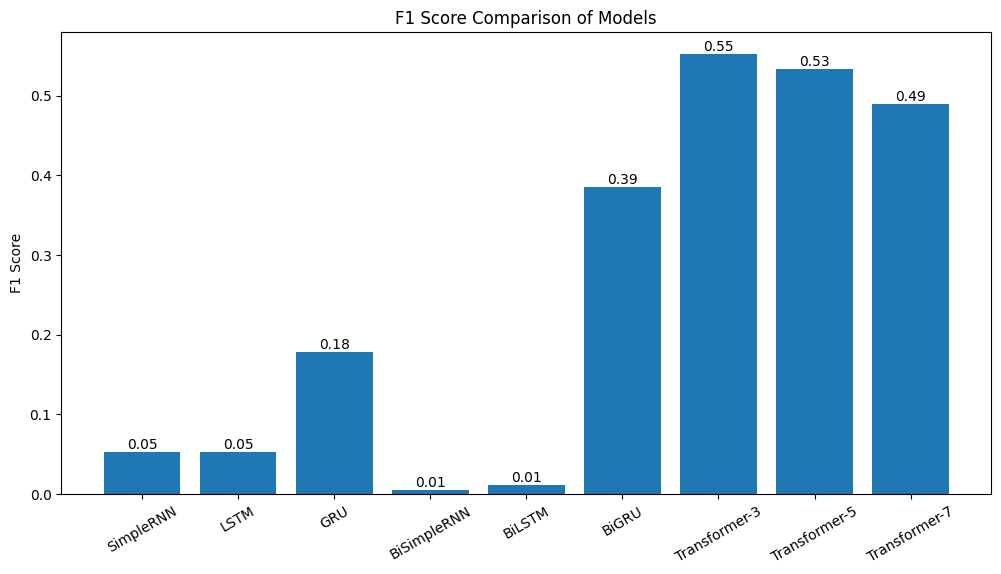

In [ ]:
plt.figure(figsize=(12, 6))
bars = plt.bar(model_names, f1_values)

plt.ylabel("F1 Score")
plt.title("F1 Score Comparison of Models")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom"
    )

plt.xticks(rotation=30)
plt.show()


## Comparison with Baseline Models

The Macro F1-scores of six baseline models from the previous assignment (SimpleRNN, LSTM, GRU, BiSimpleRNN, BiLSTM, and BiGRU) are included for comparison with the Transformer models. This comparison highlights the effectiveness of Transformer-based architectures relative to traditional RNN-based approaches for multi-class text classification.